# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Михальчук Антон Євгенійович'
ГРУПА = 'ШІ-32'
ВАРІАНТ = 13

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Михальчук Антон Євгенійович, ШІ-32, варіант 13
ваш потік:                   P>1
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
# `openpyxl` already available in the selected kernel.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [5]:
звичайне = pd.read_excel(ФАЙЛ)
display(звичайне.head())
print(звичайне.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** За замовчуванням `pandas` приймає перший рядок аркуша за заголовки. У цьому файлі перші рядки — службовий опис джерел, тому URL потрапив у назву стовпця, а справжні числові дані й назви полів не були розпізнані.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [6]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print('Розмір RAW:', RAW.shape)
display(RAW.head(30))

Розмір RAW: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [7]:
заповнені = RAW.notna().sum()
print(заповнені)

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** В аркуші три таблиці: A займає стовпці **B–O**, B — **Q–T**, C — **Y–AF**. Порожні стовпці між ними та різні кількості заповнених рядків показують, що це незалежні таблиці, вставлені в один аркуш.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [8]:
for назва, cols, last in [('A', slice(1, 15), 26), ('B', slice(16, 20), 27), ('C', slice(24, 32), 27)]:
    print(f'Таблиця {назва}:')
    display(RAW.iloc[:last, cols].dropna(how='all'))

Таблиця A:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,# Label: P >30 = Particles at >30 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Таблиця B:


,16,17,18,19
13,ftp://ftp.swpc.noaa.gov/pub/indices/old_indice...,NaN,NaN,NaN
15,Product: Daily Solar Data quar_DSD.txt,NaN,NaN,NaN
16,:Issued: 0825 UT 04 Oct 2017,NaN,NaN,NaN
17,#,NaN,NaN,NaN
18,"# Prepared by the U.S. Dept. of Commerce, NOA...",NaN,NaN,NaN
19,# Please send comments and suggestions to SWP...,NaN,NaN,NaN
23,Quarterly Daily Solar Data,NaN,NaN,NaN
26,NaN,Month,Date,Radio Flux 10.7


Таблиця C:


,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
26,NaN,NaN,# YR,MO,DA,HH,SPEED,DENSITY


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA Space Weather Prediction Center, супутник GOES-15 | протони: particles/(cm²·s·sr); електрони: electrons/(cm²·s·sr) |
| B | NOAA Space Weather Prediction Center, Quarterly Daily Solar Data | радіопотік F10.7 (sfu) |
| C | SOHO CELIAS Proton Monitor, University of Maryland | швидкість — km/s; густина — протонів/cm³ |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [9]:
A = RAW.iloc[26:, 1:15].copy()
A.columns = ['рік','місяць','день','hhmm','юліанський_день','секунди','P>1','P>5','P>10','P>30','P>50','P>100','E>0.8','E>2.0']
A = A.apply(pd.to_numeric, errors='coerce').dropna(subset=['рік'])
B = RAW.iloc[27:, 16:20].copy()
B.columns = ['рік','місяць','день','F10.7']
B = B.apply(pd.to_numeric, errors='coerce').dropna(subset=['рік'])
C = RAW.iloc[27:, 26:32].copy()
C.columns = ['рік','місяць','день','година','швидкість вітру','густина вітру']
C = C.apply(pd.to_numeric, errors='coerce').dropna(subset=['рік'])
C['рік'] += 2000
for назва, таблиця in [('A', A), ('B', B), ('C', C)]: print(назва, таблиця.shape)

A (7200, 14)
B (25, 4)
C (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [10]:
A['ts'] = pd.to_datetime(dict(year=A['рік'],month=A['місяць'],day=A['день'])) + pd.to_timedelta(A['hhmm']//100,unit='h') + pd.to_timedelta(A['hhmm']%100,unit='m')
B['ts'] = pd.to_datetime(dict(year=B['рік'],month=B['місяць'],day=B['день']))
C['ts'] = pd.to_datetime(dict(year=C['рік'],month=C['місяць'],day=C['день'],hour=C['година']))
for назва, таблиця in [('A', A), ('B', B), ('C', C)]: print(f'{назва}: {таблиця.ts.min()} — {таблиця.ts.max()}')

A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [11]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [12]:
for назва, таблиця in [('A', A), ('B', B), ('C', C)]:
    print(f'\n{назва}: розмір {таблиця.shape}; дублікати {таблиця.duplicated().sum()}')
    print(таблиця.dtypes); print('Пропуски:\n', таблиця.isna().sum())
    display(таблиця.describe(include='all'))


A: розмір (7200, 15); дублікати 0
рік                         int64
місяць                      int64
день                        int64
hhmm                        int64
юліанський_день             int64
секунди                     int64
P>1                       float64
P>5                       float64
P>10                      float64
P>30                      float64
P>50                      float64
P>100                     float64
E>0.8                     float64
E>2.0                     float64
ts                 datetime64[us]
dtype: object
Пропуски:
 рік                0
місяць             0
день               0
hhmm               0
юліанський_день    0
секунди            0
P>1                3
P>5                3
P>10               3
P>30               3
P>50               3
P>100              3
E>0.8              3
E>2.0              3
ts                 0
dtype: int64


,рік,місяць,день,hhmm,юліанський_день,секунди,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,NaN



B: розмір (25, 5); дублікати 0
рік              float64
місяць           float64
день             float64
F10.7            float64
ts        datetime64[us]
dtype: object
Пропуски:
 рік       0
місяць    0
день      0
F10.7     0
ts        0
dtype: int64


,рік,місяць,день,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



C: розмір (601, 7); дублікати 0
рік                       float64
місяць                    float64
день                      float64
година                    float64
швидкість вітру           float64
густина вітру             float64
ts                 datetime64[us]
dtype: object
Пропуски:
 рік                0
місяць             0
день               0
година             0
швидкість вітру    0
густина вітру      0
ts                 0
dtype: int64


,рік,місяць,день,година,швидкість вітру,густина вітру,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [13]:
cols_C=['швидкість вітру','густина вітру']
до=C[cols_C].agg(['mean','min'])
кількість_відємних=(C[cols_C]<0).sum()
C.loc[:,cols_C]=C[cols_C].mask(C[cols_C]<0)
після=C[cols_C].agg(['mean','min'])
print('Від’ємних значень:\n',кількість_відємних)
display(до); display(після)

Від’ємних значень:
 швидкість вітру    8
густина вітру      8
dtype: int64


,швидкість вітру,густина вітру
mean,506.547421,2.907654
min,-1.000000,-1.000000


,швидкість вітру,густина вітру
mean,513.394604,2.960371
min,277.000000,0.100000


**Відповідь 3.2:** У кожному зі стовпців C було по 8 значень `-1`. Це маркери відсутнього вимірювання, а не від’ємні швидкість чи густина. Через них середня швидкість була занижена з **513.39** до **506.55 km/s**, а середня густина — з **2.960** до **2.908 протонів/cm³**; після очищення мінімуми стали 277 km/s та 0.1 протона/см³.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [14]:
ідентифікатори_A=['рік','місяць','день','hhmm','юліанський_день','секунди']
print(A[ідентифікатори_A].describe())

          рік       місяць         день         hhmm  юліанський_день       секунди
count  7200.0  7200.000000  7200.000000  7200.000000      7200.000000   7200.000000
mean   2017.0     8.840000    13.960000  1177.500000     58005.000000  43050.000000
std       0.0     0.366632     8.775483   692.481902         7.211603  24943.113498
min    2017.0     8.000000     1.000000     0.000000     57993.000000      0.000000
25%    2017.0     9.000000     7.000000   588.750000     57999.000000  21525.000000
50%    2017.0     9.000000    13.000000  1177.500000     58005.000000  43050.000000
75%    2017.0     9.000000    19.000000  1766.250000     58011.000000  64575.000000
max    2017.0     9.000000    31.000000  2355.000000     58017.000000  86100.000000


**Відповідь 3.3:** Це `рік`, `місяць`, `день`, `hhmm`, `юліанський_день` і `секунди`. Вони є частинами часової позначки або технічними лічильниками, а не вимірюваннями: середній місяць чи середній час доби не описує фізичний стан космічної погоди.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [32]:
потоки=['P>1','P>5','P>10','P>30','P>50','P>100','E>0.8','E>2.0']
A_год=A.set_index('ts')[потоки].resample('h').agg(['mean','max'])
A_год.columns=[f'{потік}_{агрегат}' for потік,агрегат in A_год.columns]
A_год=A_год.reset_index()
display(A_год.head())

,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

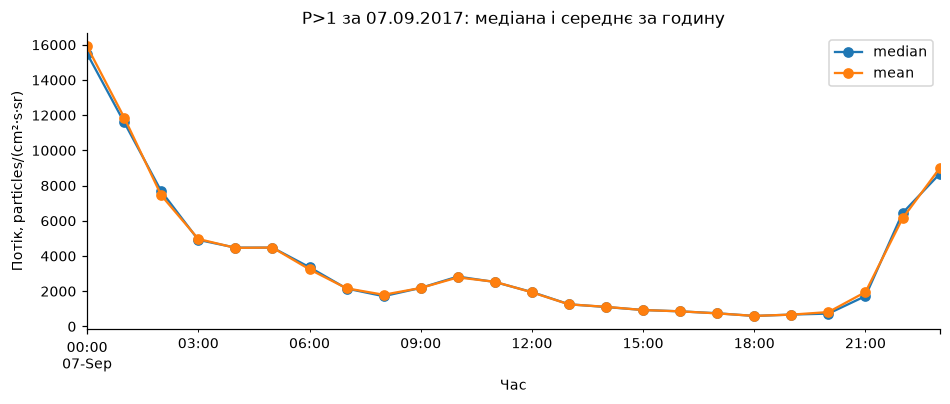

In [16]:
одна_доба=A[A.ts.dt.normalize()==pd.Timestamp('2017-09-07')].set_index('ts')['P>1'].resample('h').agg(['median','mean'])
ax=одна_доба.plot(figsize=(10,3.5),marker='o')
ax.set(title='P>1 за 07.09.2017: медіана і середнє за годину',xlabel='Час',ylabel='Потік, particles/(cm²·s·sr)')
plt.show()

**Відповідь 4.2:** Медіана показує центральне значення шести 5-хвилинних вимірювань і майже не реагує на одиничний сплеск, тоді як середнє враховує його величину. Різниця особливо важлива в годинах із короткими дуже великими піками потоку.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [17]:
C_год=C[['ts','швидкість вітру','густина вітру']]
B_год=B.set_index('ts')[['F10.7']].reindex(pd.date_range(B.ts.min(),B.ts.max()+pd.Timedelta(hours=23),freq='h')).ffill().rename_axis('ts').reset_index()
AC_зовн=A_год.merge(C_год,on='ts',how='outer')
M_inner=AC_зовн.merge(B_год,on='ts',how='inner')
M_outer=AC_зовн.merge(B_год,on='ts',how='outer')
M=M_inner.copy()
print(f'inner: {len(M_inner)}; outer: {len(M_outer)}')
display(M[M.isna().any(axis=1)])

inner: 600; outer: 601


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,швидкість вітру,густина вітру,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** Обрано `inner`: він дає **600 рядків**, тоді як `outer` дає **601**. Остання година таблиці C (22.09 00:00) не має відповідника в A і B, тому для аналізу всіх змінних одночасно її слід виключити, а не створювати рядок із пропусками.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [18]:
M['група']=pd.cut(M['P>10_max'],[-np.inf,10,1000,np.inf],labels=['тиха','активна','дуже активна'],right=False)
кількості_груп=M['група'].value_counts().reindex(['тиха','активна','дуже активна'])
print(кількості_груп)

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [19]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

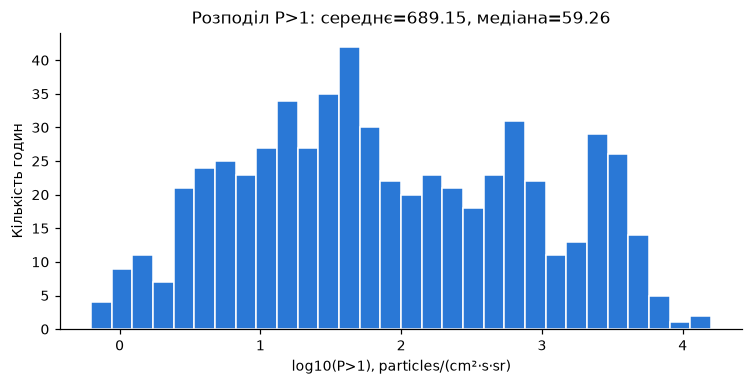

Середнє: 689.15; медіана: 59.26


In [20]:
col='P>1_mean'; середнє,медіана=M[col].mean(),M[col].median()
plt.figure(figsize=(8,3.5)); plt.hist(np.log10(M.loc[M[col]>0,col]),bins=30,color='#2a78d6',edgecolor='white')
plt.xlabel('log10(P>1), particles/(cm²·s·sr)'); plt.ylabel('Кількість годин')
plt.title(f'Розподіл P>1: середнє={середнє:.2f}, медіана={медіана:.2f}'); plt.show()
print(f'Середнє: {середнє:.2f}; медіана: {медіана:.2f}')

**Висновок:** Середнє погодинне P>1 (**689.15**) у 11.6 раза більше за медіану (**59.26**), бо розподіл має довгий правий хвіст: небагато годин зі сплесками сильно піднімають середнє.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

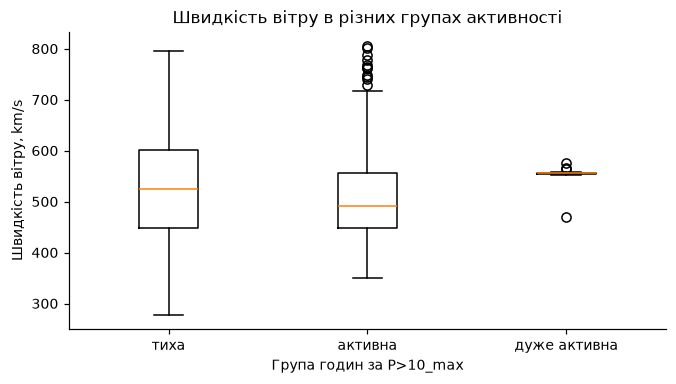

In [21]:
порядок=['тиха','активна','дуже активна']
plt.figure(figsize=(7,3.5)); plt.boxplot([M.loc[M.група==г,'швидкість вітру'].dropna() for г in порядок],tick_labels=порядок)
plt.xlabel('Група годин за P>10_max'); plt.ylabel('Швидкість вітру, km/s'); plt.title('Швидкість вітру в різних групах активності'); plt.show()

**Висновок:** Розподіли швидкості сонячного вітру у трьох групах суттєво перекриваються, тому за швидкістю вітру окремої години не можна надійно визначити групу протонної активності.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

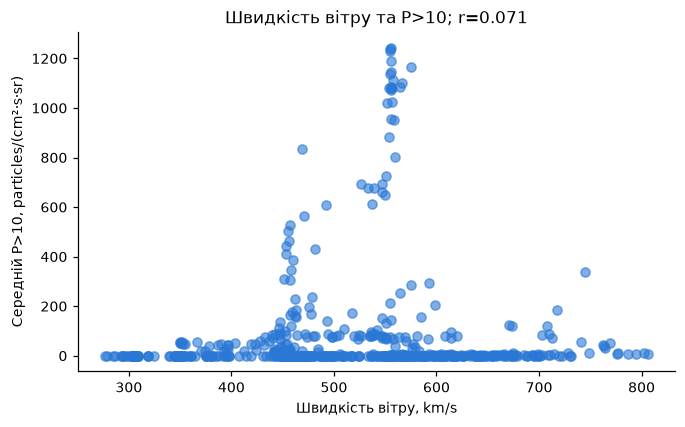

Коефіцієнт кореляції: 0.071


In [22]:
пара=M[['швидкість вітру','P>10_mean']].dropna(); кореляція=пара.corr().iloc[0,1]
plt.figure(figsize=(7,4)); plt.scatter(пара['швидкість вітру'],пара['P>10_mean'],alpha=.6,color='#2a78d6')
plt.xlabel('Швидкість вітру, km/s'); plt.ylabel('Середній P>10, particles/(cm²·s·sr)'); plt.title(f'Швидкість вітру та P>10; r={кореляція:.3f}'); plt.show()
print(f'Коефіцієнт кореляції: {кореляція:.3f}')

**Висновок:** Коефіцієнт кореляції **r = 0.071**, тобто в цих даних практично немає лінійного зв’язку між швидкістю сонячного вітру та середнім потоком P>10.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

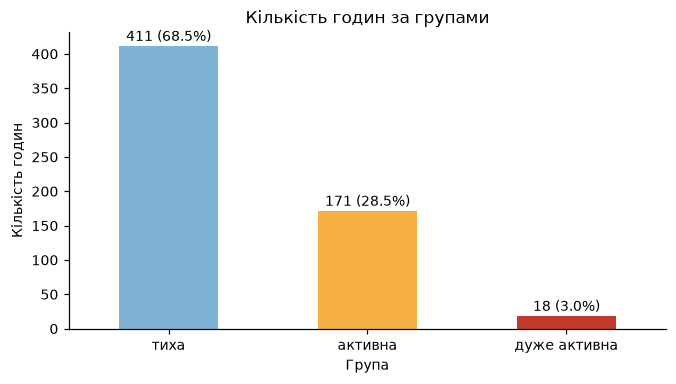

In [23]:
частки=кількості_груп/len(M)*100
ax=кількості_груп.plot.bar(figsize=(7,3.5),color=['#7fb3d5','#f5b041','#c0392b'],rot=0)
ax.set(xlabel='Група',ylabel='Кількість годин',title='Кількість годин за групами')
for i,(n,pct) in enumerate(zip(кількості_груп,частки)): ax.text(i,n+8,f'{n} ({pct:.1f}%)',ha='center')
plt.show()

**Висновок:** Тихими були **411 із 600 годин (68.5%)**, активними — **171 (28.5%)**, а дуже активними — лише **18 (3.0%)**; сильні протонні події концентруються в малій частині періоду.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

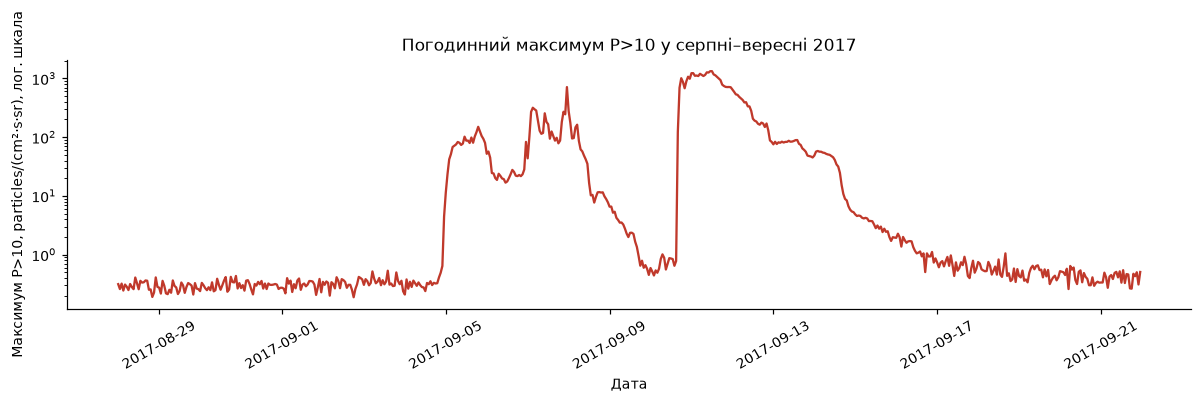

In [24]:
plt.figure(figsize=(11,3.5)); plt.plot(M.ts,M['P>10_max'],color='#c0392b'); plt.yscale('log')
plt.xlabel('Дата'); plt.ylabel('Максимум P>10, particles/(cm²·s·sr), лог. шкала'); plt.title('Погодинний максимум P>10 у серпні–вересні 2017')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

**Висновок:** На логарифмічній шкалі видно, що максимум P>10 зазвичай низький, але має короткі різкі піки; найбільший — **1330** — спостерігається 11 вересня 2017 року о 11:00.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

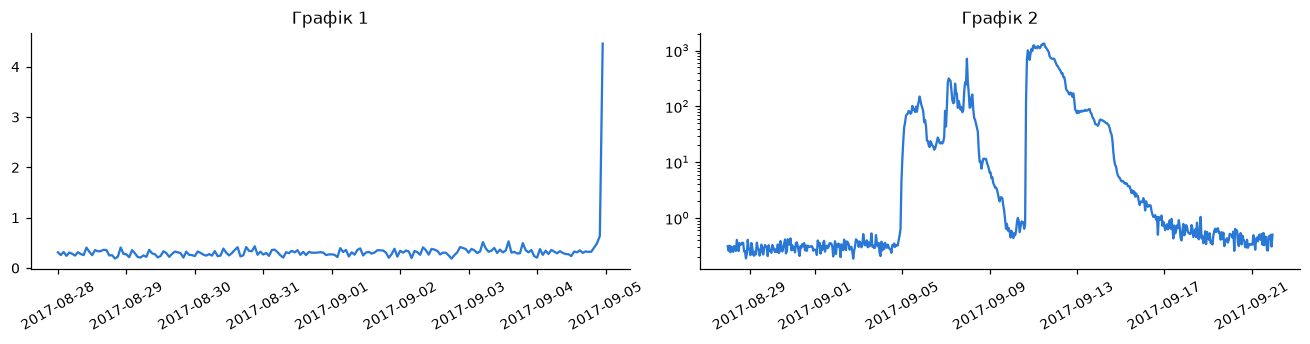

In [25]:
СТОВПЕЦЬ='P>10_max'
вікно=M[(M.ts>='2017-08-28')&(M.ts<'2017-09-05')]
fig,ax=plt.subplots(1,2,figsize=(12,3.2))
ax[0].plot(вікно.ts,вікно[СТОВПЕЦЬ],color='#2a78d6'); ax[0].set_title('Графік 1'); ax[0].tick_params(axis='x',rotation=30)
ax[1].plot(M.ts,M[СТОВПЕЦЬ],color='#2a78d6'); ax[1].set_yscale('log'); ax[1].set_title('Графік 2'); ax[1].tick_params(axis='x',rotation=30)
fig.tight_layout(); plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: у проміжку 28.08–04.09 потік P>10 був порівняно спокійним, без великих подій.
2. Висновок з другого: за весь період існували короткі різкі сплески P>10, яких перший графік не охоплює.
3. Відмінності: перший показує лише перші вісім діб, а другий — увесь період; на другому шкала Y логарифмічна, на першому — лінійна.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

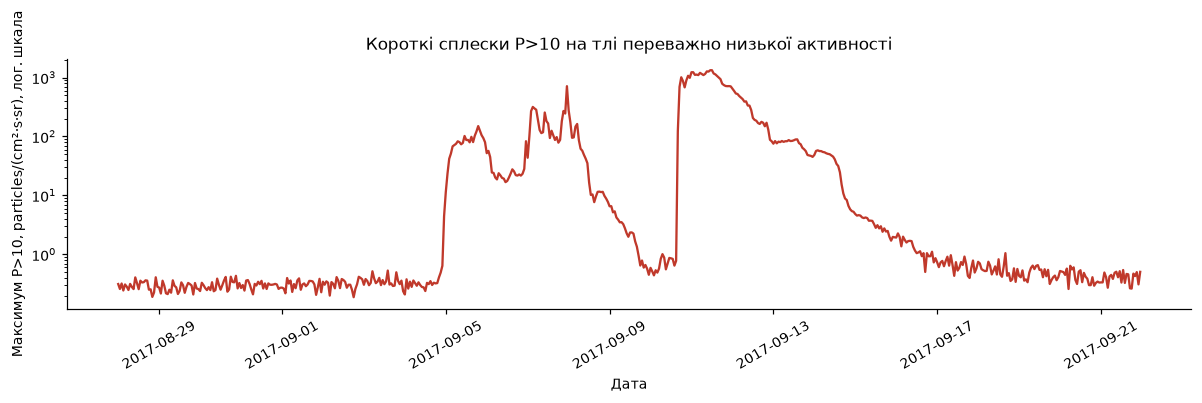

In [26]:
plt.figure(figsize=(11,3.5)); plt.plot(M.ts,M['P>10_max'],color='#c0392b'); plt.yscale('log')
plt.xlabel('Дата'); plt.ylabel('Максимум P>10, particles/(cm²·s·sr), лог. шкала'); plt.title('Короткі сплески P>10 на тлі переважно низької активності')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

**Відповідь 6.2:** Обрано повний часовий інтервал і логарифмічну шкалу Y: так не приховано великі піки, але водночас видно звичайний низький рівень потоку. Заголовок прямо формулює висновок, а не лише називає змінну.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** У C по 8 значень швидкості й густини дорівнювали `-1`; їх заміна на `NaN` підвищила середню швидкість з 506.55 до 513.39 km/s (завдання 3.2).

**Спостереження 2:** P>1 має дуже асиметричний розподіл: середнє 689.15, а медіана 59.26 (графік 1).

**Спостереження 3:** Лише 18 з 600 годин (3.0%) є дуже активними за максимумом P>10 (графіки 4 і 5).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [27]:
пік=M['P>1_mean'].idxmax(); час_піку=M.loc[пік,'ts']
вікно_24=M[(M.ts>=час_піку-pd.Timedelta(hours=12))&(M.ts<час_піку+pd.Timedelta(hours=12))]
сума_24=вікно_24['P>1_mean'].sum(); сума_всього=M['P>1_mean'].sum(); частка_24=сума_24/сума_всього
print(f'Пік: {час_піку}; сума за 24 години: {сума_24:.2f}; за весь період: {сума_всього:.2f}; частка: {частка_24:.2%}')

Пік: 2017-09-07 00:00:00; сума за 24 години: 75647.00; за весь період: 413492.61; частка: 18.29%


**Відповідь 7.2:** 24 години навколо піку P>1 (пік — **07.09.2017 00:00**) дали **75 647** з **413 492.61** за весь період, тобто **18.29%**. Майже п’ята частина сумарного потоку зосереджена лише в одній добі навколо піку.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [28]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT (Codex)'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'код, перевірено',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

ЩО_ПЕРЕВІРЕНО = ('Перевірено розміри A, B, C (7200, 25 і 601 рядок), діапазони дат 2017 року, '
                 '600 рядків у M, 411/171/18 годин у групах, очищення 8 маркерів -1 у кожному '
                 'стовпці C, кореляцію 0.071 і частку 24 годин навколо піку P>1 — 18.29%.')

ПІДТВЕРДЖУЮ = True


In [29]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Михальчук Антон Євгенійович
інструменти:                                   ChatGPT (Codex)
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                код, перевірено
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Перевірено розміри A, B, C (7200, 25 і 601 рядок), діапазони дат 2017 року, 600 рядків у M, 411/171/18 годин у групах, очищення 8 маркерів -1 у кожному стовпці C, кореляцію 0.071 і частку 24 годин навколо піку P>1 — 18.29%.
Автор підтверджує, що може пояснити к

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [30]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [31]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
